正如前面所述，LangGraph中包含的核心组件有：
- 节点（Node）：工作流中的关键工作代码，可以是工具调用、知识检索、LLM调用，用函数来定义
- 边（Edge）：也可以理解为线，就是把各个节点连接起来的路径，是控制工作流走向的关键，连接方式有：
  - 串行
  - 并行
  - 条件
- 状态（State）：整个工作流中流转的数据

由Node和Edge组成的工作流就被称为图（Graph）：

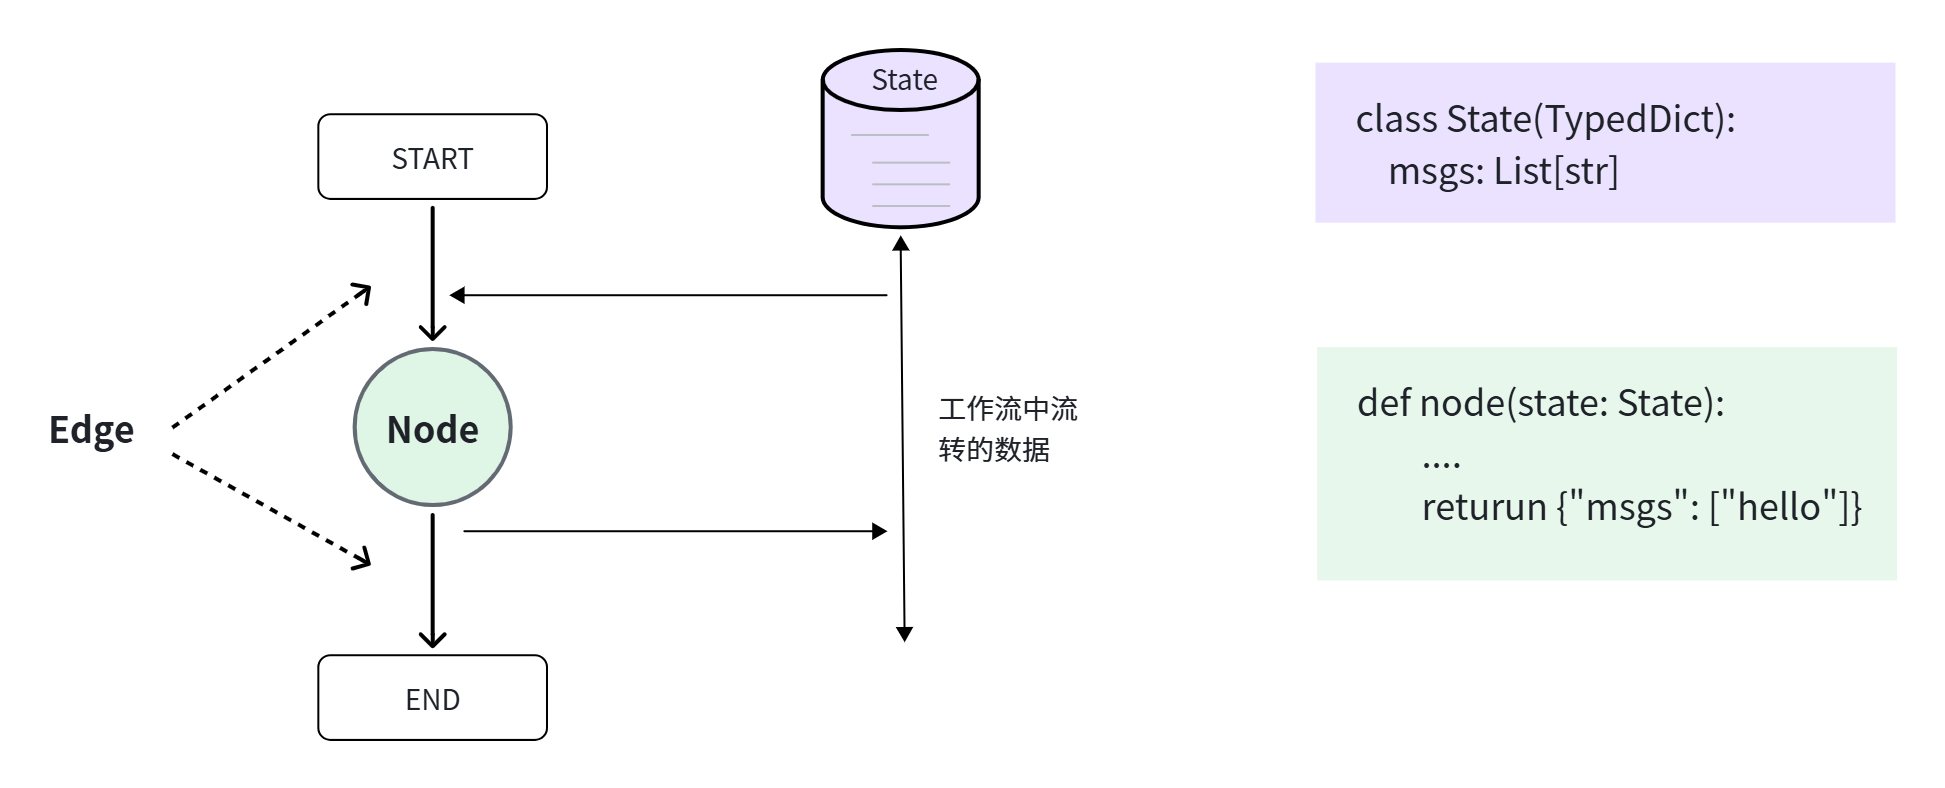

In [2]:
from typing import Annotated, TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, CachePolicy, interrupt
from langgraph.runtime import Runtime
from langgraph.types import RetryPolicy, TimeoutPolicy
from langgraph.errors import NodeError

from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, ToolMessage
)

from langchain.chat_models import init_chat_model
from langchain.tools import tool
from IPython.display import Image, display
from operator import add
from dotenv import load_dotenv
from pydantic.dataclasses import dataclass
load_dotenv()

True

# 1. 基本概念
LangGraph的核心概念有3个：Node、Edge、State

## 1.1 节点（Node）
节点（Node）是图（Graph）的执行单元，每个Node是一个Python函数。

In [ ]:
def my_node(state: State)->dict:
    # 从state读取数据
    # 执行计算逻辑（可以调用LLM、工具、数据库等）
    # 返回state的更新部分（dict）
    return {"some_key": new_value}

- 输入：完整的State对象
- 输出：一个字典，只包含要更新的字段（部分更新）
- 可以做什么：调用LLM、执行工具、读数据库、文件操作，最终把结果更新到State中...

需要注意的是，LangGraph有两个默认的Node是无需定义的，可以直接使用：
- START：开始节点，也是入口
- END：结束节点，也是出口

例子：start(用户输入name) --> 节点1（生成问候语）--> 节点2（把问候语转大写）--> end

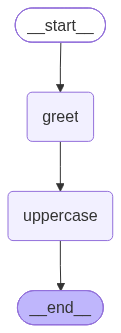

In [4]:
# 最简单的三要素示例

# 1. State: 定义共享数据结构
class SimpleState(TypedDict):
    name: str  # 记录用户名
    greeting: str  # 记录生成的问候语



# 2. Node: 定义处理逻辑
# node 1: 生成问候语的节点
def greet_node(state: SimpleState):
    """接收name, 生成greeting"""
    print(f"greet_node is receiving name: {state['name']}")
    return {"greeting": f"Hello, {state['name']}!"}

# node 2: 转大写
def uppercase_node(state: SimpleState):  
    """将greeting转为大写"""
    print(f"uppercase_node is receiving greeting: {state['greeting']}")
    return {"greeting": state["greeting"].upper()}



# 3. Edge: 编排执行顺序
graph_builder = StateGraph(SimpleState)  # 1. 用State创建图

graph_builder.add_node("greet", greet_node)  # 2. 注册节点
graph_builder.add_node("uppercase", uppercase_node)

# 创建edge连接各节点
# START -> greet -> uppercase -> END
graph_builder.add_edge(START, "greet")
graph_builder.add_edge("greet", "uppercase")
graph_builder.add_edge("uppercase", END)

# 4.编译成可执行图
graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# 执行
result = graph.invoke({"name": "World"})
print(f"结果：{result['greeting']}")

greet_node is receiving name: World
uppercase_node is receiving greeting: Hello, World!
结果：HELLO, WORLD!


## 1.2 State（状态）

State是图的共享内存，贯穿整个执行过程。
- State定义Graph中的数据字段
- 每个Node都可以获取State数据、更新的State数据（返回要更新的字段值即可）

而Node返回数据后State的更新处理方式取决于Reducers，而且State中的每个字段都有自己的Reducer。

### 1.2.1 默认Reducer
需要注意的是：如果字段没有指定Reducer，那默认的Reducer行为就是覆盖。

也就是说：如果多个Node都更新了State中的同一个字段，默认情况下后执行的Node将覆盖前面Node的更新结果。例如：

In [7]:
# 1. State: 定义共享数据结构，采用默认Reducer
class DefaultReducerState(TypedDict):
    val: str




# 2. Node: 定义处理逻辑
def node_1(state: DefaultReducerState):
    print(f"node_1 is receiving val: {state['val']}")
    return {"val": "node_1"}

def node_2(state: DefaultReducerState):
    print(f"node_2 is receiving val: {state['val']}")
    return {"val": "node_2"}




# 3. Edge: 编排执行顺序
default_reducer_graph = (
    StateGraph(DefaultReducerState)
    .add_node("node_1", node_1)
    .add_node("node_2", node_2)

    .add_edge(START, "node_1")
    .add_edge("node_1", "node_2")
    .add_edge("node_2", END)

    .compile()
)

result = default_reducer_graph.invoke(DefaultReducerState(val="default"))
print(result)

node_1 is receiving val: default
node_2 is receiving val: node_1
{'val': 'node_2'}


### 1.2.2 自定义Reducer
如果我们不希望覆盖，则需要自定义Reducer，需要用到Annotated来定义：
- Annotated[type, reducer]

In [8]:
from operator import add
from typing import Annotated, TypedDict

class CustomReducerState(TypedDict):
    count: int  # 这个字段没有定义Reducer,也就是默认会覆盖旧值
    nodes: Annotated[list[str], add]  # 这里使用add作为Reducer, 也就是会拼接结果


# 2. Node: 定义处理逻辑
def node_1(state: CustomReducerState):
    print(f"node_1 is receiving count: {state['count']}")
    return {"count": 1, "nodes": ["node_1"]}  # 直接修改nodes值，不用自己拼接


def node_2(state: CustomReducerState):
    print(f"node_2 is receiving count: {state['count']}")
    return {"count": 2, "nodes": ["node_2"]} # 直接修改nodes值，不用自己拼接

# 3. Edge: 编排执行顺序
custom_reducer_graph = (
    StateGraph(CustomReducerState)
    .add_node("node_1", node_1)
    .add_node("node_2", node_2)

    .add_edge(START, "node_1")
    .add_edge("node_1", "node_2")
    .add_edge("node_2", END)

    .compile()
)

result = custom_reducer_graph.invoke(CustomReducerState(count=0, nodes=[]))

print(result)

node_1 is receiving count: 0
node_2 is receiving count: 1
{'count': 2, 'nodes': ['node_1', 'node_2']}


可以看到，尽管Node中每次都是直接修改State的nodes字段，但最终由于使用了add这个Reducer，它会把nodes的初始值与新值拼接，类似于：

In [ ]:
nodes = []
nodes = nodes + ['node1'] + ['node2']

## 1.3 Edge（边）
Edge定义节点的执行顺序。LangGraph提供两种Edge：

| 边类型 | 方法 |
|--------|------|
| 普通边（Normal Edge） | `add_edge(node_a, node_b)` |
| 条件边（Conditional Edge） | `add_conditional_edges(node_a, router, mapping)` |

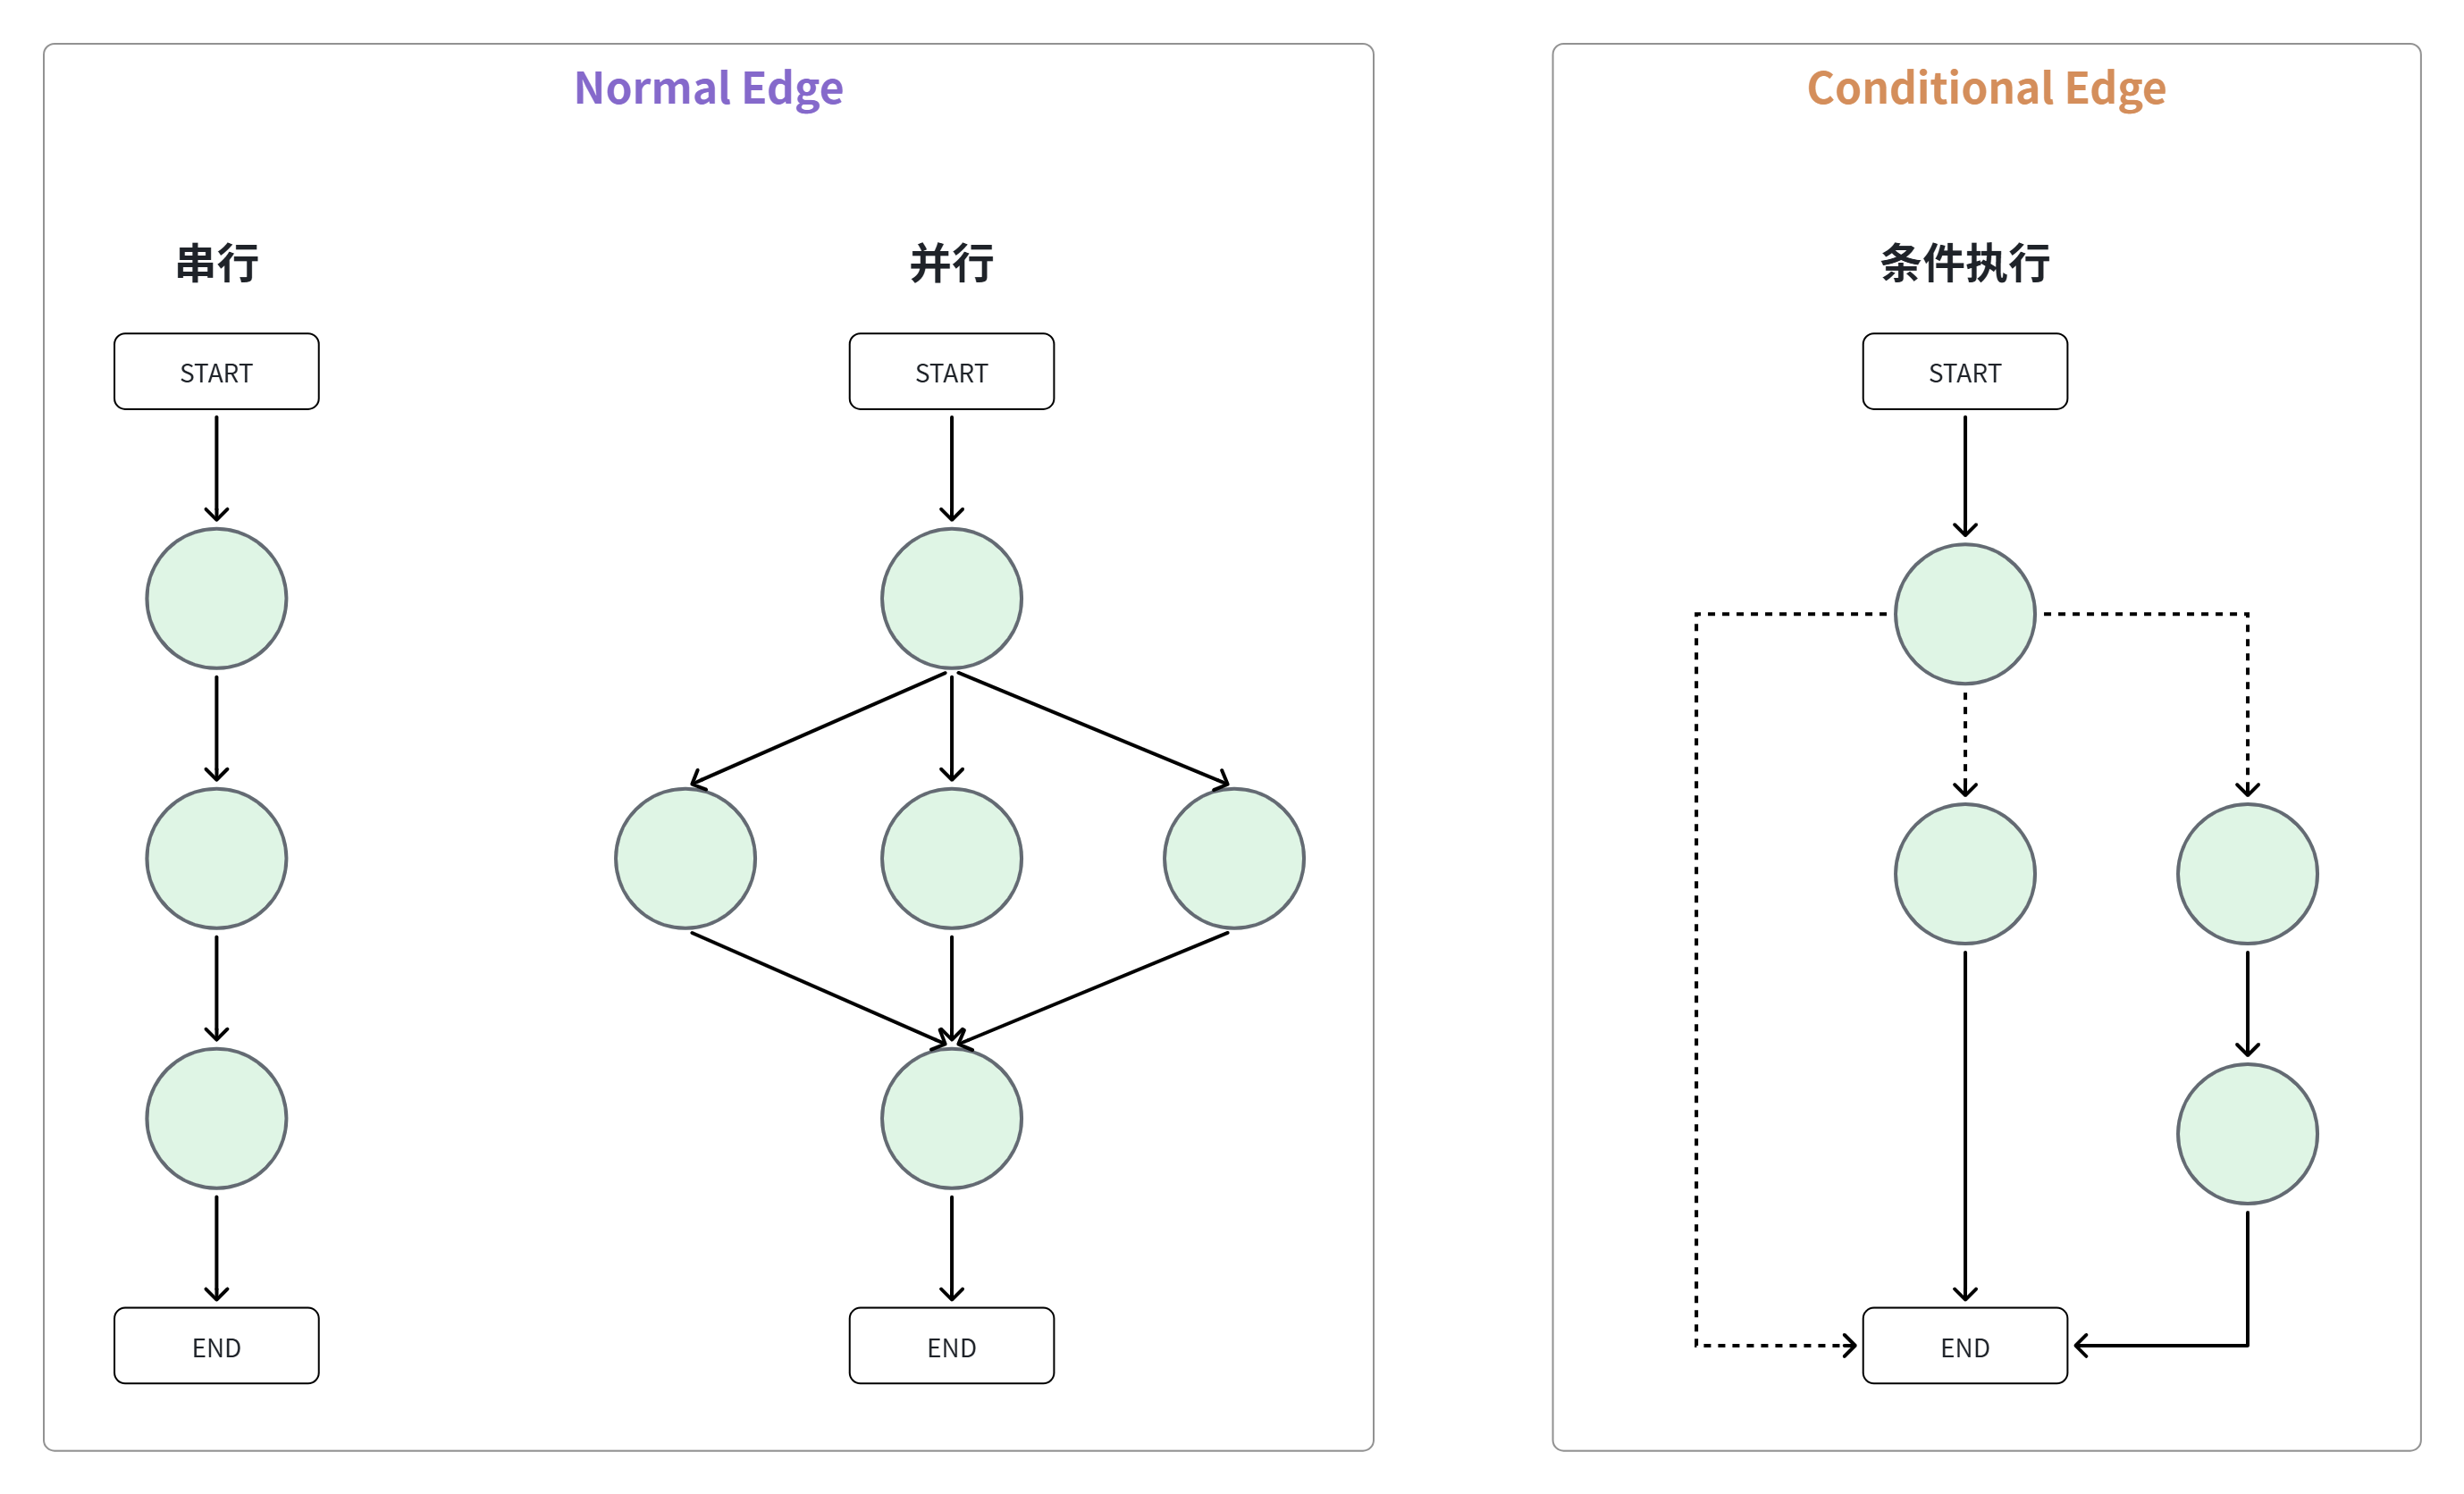

### 1.3.1 Normal Edge
普通边连接的两个节点流向是固定的，前一个节点执行完一定会执行后一个节点。不同之处在于节点之间是串行还是并行：
- 串行: 整个工作流只有一条路径，路径中的节点按照顺序依次执行
- 并行: 整个工作流有多条路径，不同路径可以同时执行

并行方式，结构如图：
      ┌──>  b ───┐
a ────┤          ├────> d
      └──>  c ───┘

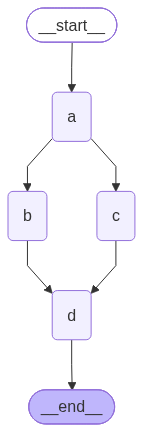

In [10]:
class ParallelState(TypedDict):
    nodes: Annotated[list[str], add]

def node_a(state: ParallelState):
    print(f"node_a is running, nodes: {state['nodes']}")
    return {"nodes": ["a"]}

def node_b(state: ParallelState):
    print(f"node_b is running, nodes: {state['nodes']}")
    return {"nodes": ["b"]}

def node_c(state: ParallelState):
    print(f"node_c is running, nodes: {state['nodes']}")
    return {"nodes": ["c"]}

def node_d(state: ParallelState):
    print(f"node_d is running, nodes: {state['nodes']}")
    return {"nodes": ["d"]}

parallel_graph = (
    StateGraph(ParallelState)
    .add_node("a", node_a)
    .add_node("b", node_b)
    .add_node("c", node_c)
    .add_node("d", node_d)

    .add_edge(START, "a")
    .add_edge("a", "b")   # a -> b
    .add_edge("a", "c")   # a -> c
    .add_edge("b", "d")   # b -> d
    .add_edge("c", "d")   # c -> d

    .add_edge("d", END)
    .compile()
)

display(Image(parallel_graph.get_graph().draw_mermaid_png()))

In [11]:
result = parallel_graph.invoke(ParallelState(nodes=[]))
print(result)

node_a is running, nodes: []
node_b is running, nodes: ['a']
node_c is running, nodes: ['a']
node_d is running, nodes: ['a', 'b', 'c']
{'nodes': ['a', 'b', 'c', 'd']}


### 1.3.2 Conditional Edge

条件边的添加方式如下：

add_conditional_edges(node_a, router, mapping)

接收三个参数：
- node_a：是当前节点
- router：路由函数，逻辑自定义，它的返回值默认就是下个节点的名字。
- mapping：如果router返回值与下个节点名不一样，可以用mapping定义返回值与下个节点名字的映射关系

router可以根据情况返回不同的结果，但一次只能有一个结果。也就是说Conditional Edge连接的多个节点有且只有1个会成为next_node。

例如，我们实现一个成绩判定的Graph，用户输入一个分数，我们根据分数判断走哪个节点：
- 大于60，走成功节点
- 小于60，走失败节点

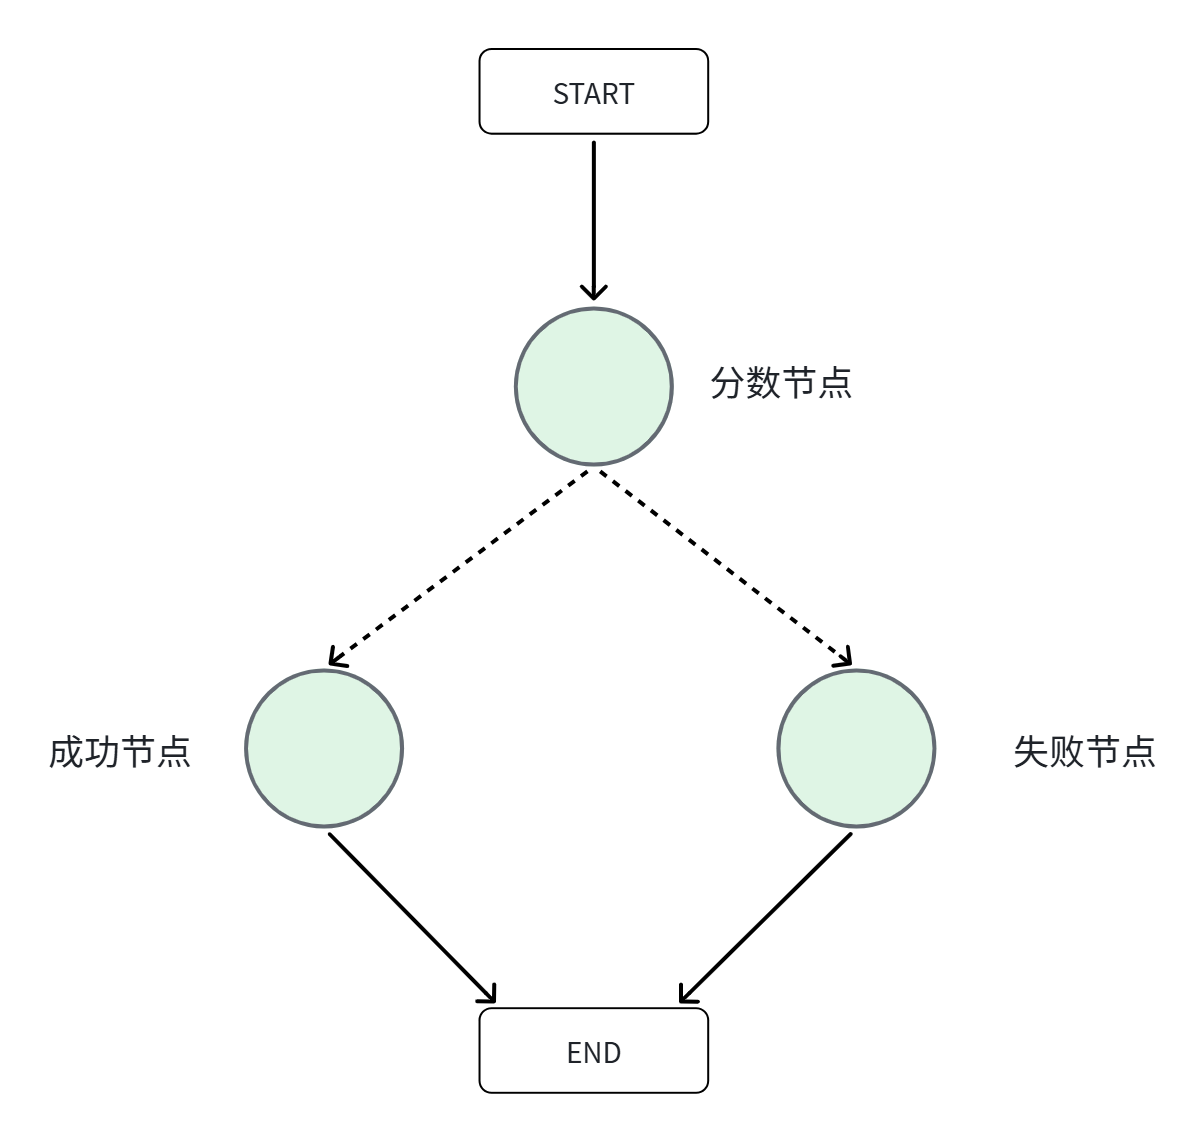

In [ ]:
# 条件边示例：根据state决定走哪条路
class RouteState(TypedDict):
    score: int
    result: str

def scorer(state: RouteState):
    score = int(input("请输入分数"))
    print(score)
    return {"score": score}

def pass_node(state: RouteState):
    return {"result": "通过！"}

def fail_node(state: RouteState):
    return {"result": "不通过！"}

def router(state: RouteState) -> Literal["pass", "fail"]:
    """根据score决定下一节点"""
    if state["score"] >= 60:
        return "pass"
    return "fail"

condition_graph = (
    StateGraph(RouteState)          # 1.创建Graph
                                    # 2.添加节点
    .add_node("scorer", scorer)         # 打分节点
    .add_node("pass", pass_node)        # 失败节点
    .add_node("fail", fail_node)        # 成功节点
                                    # 3.添加Edge
    .add_edge(START, "scorer")               # start -> scorer
    .add_conditional_edges("scorer", router) # scorer -> conditional_edge(router)
    .add_edge("pass", END)                   # pass -> end
    .add_edge("fail", END)                   # fail -> end
    .compile()
)

result = condition_graph.invoke({"score": 0, "result": ""})

print(f"score={result["score"]} -> {result["result"]}")

95
score=95 -> 通过！


### 1.3.3 Command实现条件分支
如果不想编写Conditional Edge，也可以在Node中直接返回下个节点信息。
但是，由于Node必须返回对State的更新，而没有条件边就需要返回下个节点的名字。函数返回值只能有一个。所以LangGraph就提供了Command API，用Command来指定下个节点以及要更新的字段。

In [ ]:
def node_a(state: State) -> Command[Literal['node_b', 'node_c']]:
    # ...
    return Command(
        update={"k":"v"},
        goto="node_b"
    )

- update : 用来指定要更新的State字段
- goto : 用来指定下个节点

In [ ]:
# 在Node中基于Command实现条件分支

class RouteState(TypedDict):
    score: int
    result: str

def scorer(state: RouteState) -> Command[Literal["fail", "pass"]]:
    score = int(input("请输入分数"))

    next_node = "pass" if score >= 60 else "fail"

    return Command(
        update=RouteState(score=score),  # 通过update更新state字段
        goto=next_node
    )

def pass_node(state: RouteState):
    return {"result": "通过！"}

def fail_node(state: RouteState):
    return {"result": "不通过"}

command_condition_graph = (
    StateGraph(RouteState)  # 创建Graph
    # 添加节点
    .add_node("scorer", scorer)
    .add_node("pass", pass_node)
    .add_node("fail", fail_node)

    .add_edge(START, "scorer")
    .add_edge("pass", END)
    .add_edge("fail", END)

    .compile()
)

result = command_condition_graph.invoke({"score": 0, "result": ""})

print(f"score={result["score"]} -> {result["result"]}")

# 2. LangGraph构建Agent

## 2.1 基础LLM调用工作流

In [14]:
llm = init_chat_model("deepseek-v4-flash")

# 定义State
class SimpleAgentState(TypedDict):
    user_input: str
    result: str

# 定义LLM调用Node
def call_llm(state: SimpleAgentState):
    # 调用llm
    response = llm.invoke(state['user_input'])

    # 更新state
    return {"result": response.content}

# 创建Graph
llm_graph = (
    StateGraph(SimpleAgentState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile()
)

result = llm_graph.invoke(SimpleAgentState(user_input="你好", result=""))
print(result)

{'user_input': '你好', 'result': '你好！有什么可以帮你的吗？'}


## 2.2 消息历史
目前的Graph中，State比较简单，只记录了两个值：
- user_input: 一次用户输入
- result: 一次LLM结果
然后实际在复杂的Agent中，用户会多次与LLM交互，还有工具调用，产生大量的历史消息，这些消息都需要记录下来。因此，我们的State需要重新设计。

### 2.2.1 自定义消息历史State
在之前学习LangChain时我们知道，Agent交互时的消息类型有很多：SystemMessage、AIMessage、HumanMessage、ToolMessage等。而这些消息都有一个共同的父类：BaseMessage。

因此，我们可以在State中定义一个字段，类型为list[BaseMessage]。但这还不够，由于要不断添加新的消息到这个list，所以还需要一个Reducer，而LangChain正好提供了这样的一个Reducer：add_message

In [15]:
from langgraph.graph.message import add_messages
from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, ToolMessage
)

class MessageAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

add_message这个Reducer的效果就是不断累积消息，形成Message列表：

In [16]:
messages = [SystemMessage(content="你是一个热心助人的AI助手，你的名字叫武藏")]

messages = add_messages(messages, HumanMessage(content="你好，你是谁？"))

print(messages)

[SystemMessage(content='你是一个热心助人的AI助手，你的名字叫武藏', additional_kwargs={}, response_metadata={}, id='8ed8f40b-0ee3-4d8c-a6f0-46d10836aec7'), HumanMessage(content='你好，你是谁？', additional_kwargs={}, response_metadata={}, id='fbe8a0e2-06de-4729-ba57-65c67b318245')]


In [17]:
from langgraph.graph.message import add_messages

class MessageAgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# 初始化模型
llm = init_chat_model("deepseek-v4-flash")

# 定义LLM调用node
def call_llm(state: MessageAgentState):
    # 调用llm
    response = llm.invoke(state['messages'])
    # 更新state
    return {"messages": [response]}

# 创建Graph
llm_graph = (
    StateGraph(MessageAgentState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile()
)

result = llm_graph.invoke({"messages": messages})
print(result)

{'messages': [SystemMessage(content='你是一个热心助人的AI助手，你的名字叫武藏', additional_kwargs={}, response_metadata={}, id='8ed8f40b-0ee3-4d8c-a6f0-46d10836aec7'), HumanMessage(content='你好，你是谁？', additional_kwargs={}, response_metadata={}, id='fbe8a0e2-06de-4729-ba57-65c67b318245'), AIMessage(content='你好！我是武藏，一个热心助人的AI助手。有什么我可以帮你的吗？无论是学习、工作上的问题，还是生活、娱乐上的需要，我都乐意尽力协助！ 😊', additional_kwargs={'refusal': None, 'reasoning_content': '好的，用户用中文打招呼并询问我的身份。这是一个非常简单的自我介绍场景。\n\n用户可能刚接触我，想确认我的基本信息和能力范围。深层需求是建立初步信任，了解我能提供什么帮助。\n\n想到了用友好热情的语气直接回应，先报出名字“武藏”，再简要说明我的功能和定位，最后主动询问用户需求，以开启对话。回复结构可以简洁明了。'}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 100, 'total_tokens': 224, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 83, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 100}, 'model_pr

### 2.2.2 默认的MessageState
事实上，记录Agent消息的场景非常常见，所以LangGraph中还提供了一个默认的State，专门用来记录消息历史，叫做MessageState：

In [ ]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

所以，如果只是为了记录消息历史，我们可以不用定义State了，直接用MessageState：

In [18]:
from langgraph.graph.message import add_messages, MessagesState

# 1.先初始化一个模型
llm = init_chat_model("deepseek-chat")

# 2.定义LLM调用Node
def call_llm(state: MessagesState):
    # 调用llm，得到结果
    response = llm.invoke(state['messages'])
    # 更新state
    return {"messages": [response]}

# 3.创建Graph
llm_graph = (
    StateGraph(MessagesState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile()
)
result = llm_graph.invoke({"messages": "一加一等于多少"})
print(result)

{'messages': [HumanMessage(content='一加一等于多少', additional_kwargs={}, response_metadata={}, id='96b85f75-ff6e-4b7b-a508-3a3823614b0f'), AIMessage(content='这个问题看似简单，但在不同情境下有不同的答案：\n\n- **数学上**：严格等于 **2**。\n- **计算机二进制中**：1 + 1 = **10**（读作“一零”）。\n- **如果“1”代表队列**：1 + 1 = **1**（两个队列合并成一个队列）。\n- **幽默或哲学上**：可能等于“王”（汉字拆字：一+一+十？），或者“3”（如果1+1指一个男人+一个女人，可能生个孩子）。\n\n不过，最普适的答案是：**2**。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 9, 'total_tokens': 135, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 9}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '80cf64c9-179b-4c3c-9769-ee08b631711f', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ff4cf-f498-7c90-b380-94e74c76994c-0', tool_calls=[], 

## 2.3 会话记忆
有了历史并不等于有记忆，记忆必须基于会话id(thread_id)来分别管理会话历史。这就要靠LangGraph中的Checkpointer来实现了。

之前在LangChain中我们就是导入的LangGraph提供的Checkpointer来实现记忆的，这里也一样。我们用默认的InMemorySaver来演示。

In [19]:
from langgraph.checkpoint.memory import InMemorySaver

# 1.先初始化一个模型
llm = init_chat_model("deepseek-chat")

# 2.定义LLM调用Node
def call_llm(state: MessagesState):
    # 调用llm，得到结果
    response = llm.invoke(state['messages'])
    # 更新state
    return {"messages": [response]}

# 3.创建Graph
memory_graph = (
    StateGraph(MessagesState)
    .add_node("llm", call_llm)
    .add_edge(START, "llm")
    .add_edge("llm", END)
    .compile(checkpointer=InMemorySaver()) # 注意，在compile时指定Checkpointer
)

# 4.测试
# 依然要通过config中的thread_id来区分不同会话
config = {"configurable": {"thread_id": "1"}}
result = memory_graph.invoke(
    {"messages": [HumanMessage("你好，我是虎哥")]},
    config
)
result = memory_graph.invoke(
    {"messages": [HumanMessage("我是谁?")]},
    config
)
print(result)

{'messages': [HumanMessage(content='你好，我是虎哥', additional_kwargs={}, response_metadata={}, id='d0398357-4411-47b4-8299-ccbcfa2ea434'), AIMessage(content='你好虎哥！👋 很高兴见到你！我是DeepSeek，你的AI助手。\n\n既然你自称“虎哥”，那我猜你可能是：\n- **属虎**的？\n- 还是**名字里带虎**？\n- 或者就是**霸气外露**，自称虎哥？😄\n\n不管怎样，很高兴认识你！今天有什么我可以帮你的吗？无论是：\n- 💼 工作学习上的问题\n- 💡 创意灵感碰撞\n- 🤔 生活疑惑解答\n- 🎯 或者其他任何你想聊的\n\n虎哥尽管开口，我随时在线！你想聊点啥？', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 9, 'total_tokens': 141, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cache_write_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 9}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '8a1ffe68-d395-4907-ac9c-e1844ca91bd3', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ff4d3-c949-7ab2-8d0a-06b8ef1f588c-0', tool_calls=[], inva

## 2.4 带工具调用的LLM工作流
Agent通常是绑定了工具的LLM。它没有固定的工作流，而是采用ReAct行为模式：
1. 把问题交给LLM处理（Reasoning）
    1. 判断是否需要调用工具
    2. 要调用哪个工具
2. 调用工具（Action）
3. 拿到工具结果，返回结果给LLM，判断是否能回答问题（回到1）
4. 生成响应，结束

### 2.4.1 定义Tool

In [26]:
from langchain.tools import tool
# ====== Step 1: 准备工具和模型 ======
# 工具
@tool
def get_weather(city: str) -> str:
    """获取城市天气"""
    weather_data = {
        "北京": "晴天 25度",
        "上海": "多云 28度",
        "杭州": "小雨 22度",
    }
    return weather_data.get(city, f"未找到{city}的天气信息")

@tool
def square_root(x: float) -> str:
    """Calculate the square root of a number"""
    return x ** 0.5

# 组成工具数组
tools = [get_weather, square_root]
# 组成工具名和工具的映射，方便查找工具
tools_by_name = {t.name: t for t in tools}
# 定义模型
model = init_chat_model("deepseek-chat")
# 绑定工具到模型
model_with_tools = model.bind_tools(tools)

需要注意的，手动调用带工具的模型，模型会返回要执行的工具的信息，我们需要解析这些信息，拿到要调用的工具名称和参数，自己去调用。
所以，我们才在上面建立了工具name与工具的映射。
另外，等一下定义Node的时候就需要自己调用Tool.

### 2.4.2 定义Node

In [ ]:

# ====== Step 2: 定义Node函数 ======
def llm_node(state: MessagesState):
    """LLM节点：调用模型，可以选择调用工具"""
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def tool_node(state: MessagesState) -> Command:
    """工具节点：执行LLM要求的工具调用"""
    last_message = state["messages"][-1]
    results = []
    # AI可能一次返回多个工具调用，所以需要循环处理，再收集结果
    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        results.append(ToolMessage(
            content=result,
            tool_call_id=tool_call["id"]
        ))
    return {"messages": results}

def should_continue(state: MessagesState) ->  Literal["tools", END]:
    """路由函数：判断下一步是继续调工具还是结束"""
    last_message = state["messages"][-1]
    # 如果包含tool_calls，则跳转到tools节点，没有则跳转到END节点
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "tools"  # 有工具调用 -> 去工具节点
    return END           # 没工具调用 -> 结束

print("Step 2 完成: Node函数已定义")

Step 2 完成: Node函数已定义


### 2.4.3 构建Graph

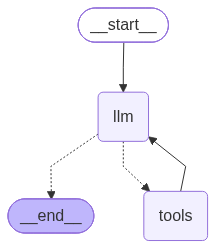

In [31]:
# ====== Step 3: 构建图 ======
agent_graph = (
    StateGraph(MessagesState)
    .add_node("llm", llm_node)
    .add_node("tools", tool_node)
    .add_edge(START, "llm")
    .add_conditional_edges("llm", should_continue)
    .add_edge("tools", "llm")  # 工具执行后回到LLM，形成循环
    .compile()
)

display(Image(agent_graph.get_graph().draw_mermaid_png()))

command写法

In [32]:
# Command写法
def llm_node(state: MessagesState):
    """LLM节点：调用模型，可以选择调用工具"""
    response = model_with_tools.invoke(state["messages"])
    next_node = "tools" if response.tool_calls else END
    return Command(
        update={"messages": [response]},
        goto=next_node
    )

def tool_node(state: MessagesState) -> Command:
    """工具节点：执行LLM要求的工具调用"""
    last_message = state["messages"][-1]
    results = []
    # AI可能一次返回多个工具调用，所以需要循环处理，再收集结果
    for tool_call in last_message.tool_calls:
        tool = tools_by_name[tool_call["name"]]
        result = tool.invoke(tool_call["args"])
        results.append(ToolMessage(
            content=result,
            tool_call_id=tool_call["id"]
        ))
    return Command(
        update={"messages": results}, 
        goto="llm"
    )

In [ ]:
# ====== Step 3: 构建图 ======
agent_graph = (
    StateGraph(MessagesState)
    .add_node("llm", llm_node)
    .add_node("tools", tool_node)
    # Command 的 goto 本身就是一条动态边。节点返回 Command(goto="tools") 的效果等同于告诉你"下一站去哪"，不需要再画一条静态边。
    .add_edge(START, "llm")
    .compile()
)

# draw_mermaid_png() 只能画静态边——add_edge 和 add_conditional_edges。Command 的 goto 是运行时决定的动态路由，编译时图结构里没有这条边，Mermaid 自然画不出来。